In [1]:
import ima_takeda as tkd

import numpy as np
import pandas as pd

# If We Only Have T Cell Trajectory

In [2]:
# Load data to fit
df: pd.DataFrame = pd.read_csv("data/lab_data_from_hour_32.csv")

In [3]:
obs_T = np.array(df["tumor_cells_E1"])
obs_T0 = int(obs_T[0])
obs_E0 = int(df["CART_cells_E1"].iloc[0])
obs_E_final = int(df["CART_cells_E1"].iloc[-1])

In [4]:
# Set the fitting parameter
# If the value is set as a tuple (a, b), then the fitting engine will try to find the best fit of that parameter in the range.
# (The parameter 'early_stop' is an exception)
# If the value is set as a single value, then the engine will treat it as a known variable.

param_spec: dict = dict(
    E_0=obs_E0,
    T_0=obs_T0,
    r=(0.001, 0.05),
    m=(0.001, 0.05),
    N=len(obs_T) - 1,
    L=1.0,
    k_on=(0.0, 1.0),
    k_off=(0.0, 1.0),
    k_kill=(0.0, 1.0),
    g_E=(0.0, 1.0),
    g_T=(0.0, 1.0),
    early_stop=(True, 200, 0.0),
)

# Uncomment the following line to actually run the fitting
# With the current para_spec run time will be long (many parameters to fit)
# sim_config: dict = tkd.fit_params_weighted_T_ONLY(param_spec=param_spec, obs_T=obs_T, obs_E_final=obs_E_final, n_runs=20, w_T=1, w_E_final=2)

# If We Have All Trajectories

In [5]:
# Load data to fit
df: pd.DataFrame = pd.read_csv("data/ODE_synthetic_data.csv")
obs_T: np.ndarray = np.concatenate(([100], np.array(df["T_data"])))
obs_E: np.ndarray = np.concatenate(([100], np.array(df["E_data"])))
obs_C: np.ndarray = np.concatenate(([0], np.array(df["C_data"])))

In [6]:
# Set the fitting parameter
# If the value is set as a tuple (a, b), then the fitting engine will try to find the best fit of that parameter in the range.
# (The parameter 'early_stop' is an exception)
# If the value is set as a single value, then the engine will treat it as a known variable.
# In the following example, only k_on is being fitted.
param_spec: dict = dict(
    E_0=100,
    T_0=100,
    r=0.05,
    m=0.05,
    N=100,
    L=1.0,
    k_on=(0.0, 1.0),
    k_off=0.005,
    k_kill=0.002,
    g_E=0.0,
    g_T=0.01,
    early_stop=(True, max(obs_T / (obs_E + obs_C)) * 10, 0.0),
)

sim_config: dict = tkd.fit_params(param_spec, obs_E, obs_T, obs_C, n_runs=30)

Simulating (E>0):   0%|          | 0/100 [00:00<?, ?it/s]

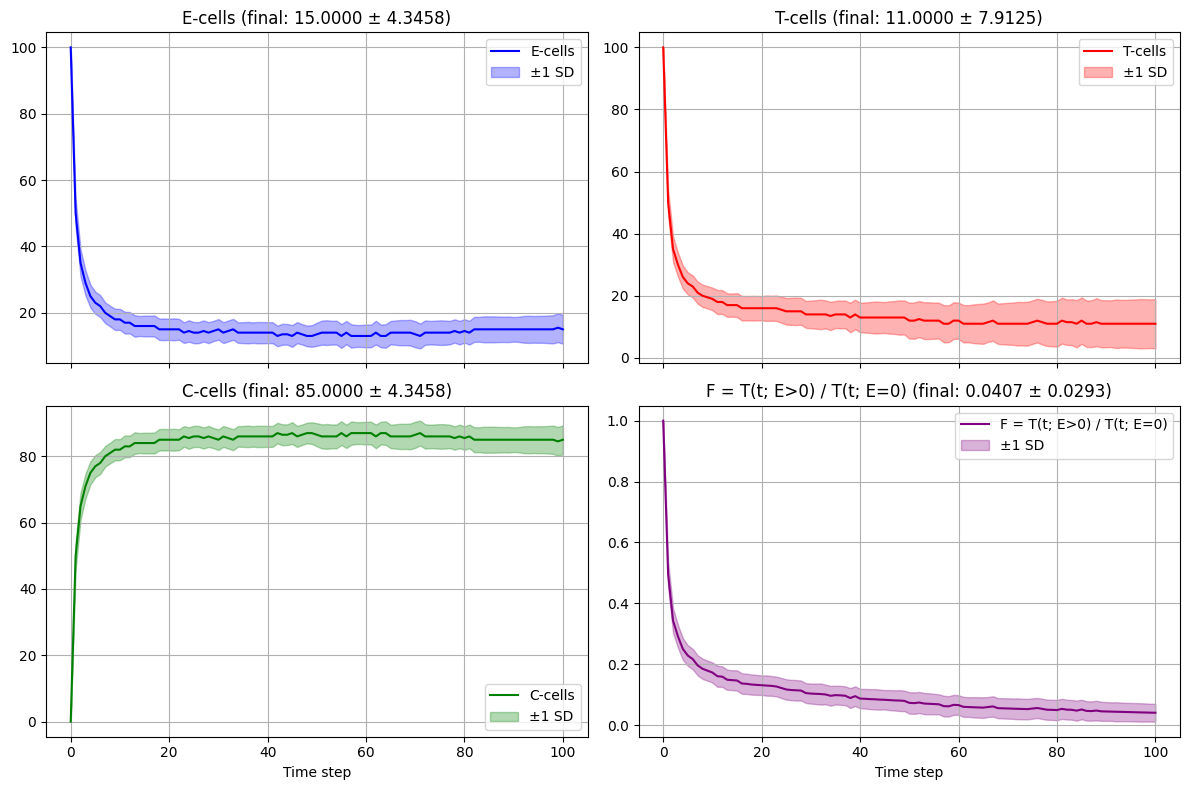

In [7]:
# Fitted Data
monte_carlo, monte_carlo_baseline = tkd.single_scenario_monte_carlo(n_runs=100, sim_kwargs=sim_config, seed_offset=9999)
tkd.plot_result_trend(monte_carlo, use_median=True)